<a href="https://www.kaggle.com/code/ameythakur20/predicting-smartphone-addiction" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<br clear="all">

<h1 align="center">Predicting Smartphone Addiction</h1>

<p align="center">
  <b>A Multi-Stage Meta-Feature Stacking architecture combining target-encoded behavioral representations with high-capacity gradient boosted meta-learning.</b>
</p>

<p align="center">
  <a href="https://www.kaggle.com/competitions/playground-series-s6e8"><img alt="Competition" src="https://img.shields.io/badge/Competition-Playground_S6E8-20BEFF?logo=kaggle&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur/KAGGLE-COMPETITIONS/tree/main/Competitions/Predicting%20Smartphone%20Addiction"><img alt="Repository" src="https://img.shields.io/badge/Repository-KAGGLE--COMPETITIONS-181717?logo=github&logoColor=white"></a>
  &nbsp;
  <a href="https://github.com/Amey-Thakur"><img alt="Author" src="https://img.shields.io/badge/Author-Amey_Thakur-0969DA"></a>
  &nbsp;
  <a href="https://orcid.org/0000-0001-5644-1575"><img alt="ORCID" src="https://img.shields.io/badge/ORCID-0000--0001--5644--1575-A6CE39"></a>
  &nbsp;
  <img alt="License" src="https://img.shields.io/badge/License-Apache_2.0-lightgrey">
</p>

<p align="center">
  <a href="#problem">1. Problem</a> &nbsp;&middot;&nbsp;
  <a href="#setup">2. Setup</a> &nbsp;&middot;&nbsp;
  <a href="#data">3. Data</a> &nbsp;&middot;&nbsp;
  <a href="#exploration">4. Exploration</a> &nbsp;&middot;&nbsp;
  <a href="#features">5. Strategy</a> &nbsp;&middot;&nbsp;
  <a href="#validation">6. Validation</a> &nbsp;&middot;&nbsp;
  <a href="#base-models">7. Base Learners</a> &nbsp;&middot;&nbsp;
  <a href="#meta-stacking">8. Meta-Stacking</a> &nbsp;&middot;&nbsp;
  <a href="#results">9. Results</a> &nbsp;&middot;&nbsp;
  <a href="#submission">10. Submission</a> &nbsp;&middot;&nbsp;
  <a href="#improvements">11. Next Steps</a>
</p>

<hr>

<a name="problem"></a>
## 1. Problem

The Playground Series Season 6 Episode 8 competition requires predicting the probability of smartphone addiction (`addicted_label`) from self-reported behavioral and demographic metrics. The evaluation metric is the **Area Under the ROC Curve (AUC)**.

Tabular behavioral datasets of this structure exhibit sharp non-linear boundaries where individual features (e.g. social media usage vs. total screen duration) interact conditionally. The primary challenge is constructing robust continuous interaction metrics while preventing data leakage and overfitting across high-capacity gradient boosted trees.

<br>

---

<a name="setup"></a>
## 2. Setup

Imports, seed locking, compute configuration, and path discovery.

<br>

In [1]:
import os
import sys
import glob
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import logit
from scipy.stats import rankdata
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve

# Gradient Boosters
from lightgbm import LGBMClassifier, plot_importance
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# Kaggle Toolbox & Cloud Fallback
sys.path.append("../../Kaggle Toolbox")
sys.path.append("/kaggle/usr/lib/ameythakur20/kaggle_toolbox")
sys.path.append("/kaggle/usr/lib/notebooks/ameythakur20/kaggle_toolbox")

try:
    import kaggle_toolbox as tb
except ImportError:
    class DummyTB:
        @staticmethod
        def seed_everything(seed=42):
            import random
            random.seed(seed)
            np.random.seed(seed)
            os.environ["PYTHONHASHSEED"] = str(seed)
        @staticmethod
        def reduce_mem_usage(df):
            for col in df.columns:
                col_type = df[col].dtype
                if col_type != object and not pd.api.types.is_categorical_dtype(df[col]):
                    c_min, c_max = df[col].min(), df[col].max()
                    if str(col_type)[:3] == "int":
                        if c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                            df[col] = df[col].astype(np.int32)
                    else:
                        if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                            df[col] = df[col].astype(np.float32)
            return df
        @staticmethod
        def missing_report(df):
            return df.isnull().sum()
        @staticmethod
        def timer(name=""):
            import contextlib, time
            @contextlib.contextmanager
            def _t():
                t0 = time.time()
                yield
                print(f"[{name}] Completed in {time.time() - t0:.2f}s")
            return _t()
        @staticmethod
        def check_submission(sub, sample):
            assert sub.shape == sample.shape, "Shape mismatch against sample submission."
            assert list(sub.columns) == list(sample.columns), "Column schema mismatch."
            assert sub.isnull().sum().sum() == 0, "Submission contains NaN values."
            print("Submission verification passed:", sub.shape)
    tb = DummyTB()

# Global Deterministic Seed
SEED = 42
tb.seed_everything(SEED)

# Dynamic Cloud vs Local Data Directory Resolution
train_matches = glob.glob("/kaggle/input/**/train.csv", recursive=True) or glob.glob("**/train.csv", recursive=True) or ["train.csv"]
TRAIN_PATH = train_matches[0]
DATA_DIR = os.path.dirname(TRAIN_PATH) or "."
TEST_PATH = os.path.join(DATA_DIR, "test.csv")
SAMPLE_SUB_PATH = os.path.join(DATA_DIR, "sample_submission.csv")

print(f"Resolved Data Directory: {DATA_DIR}")
print(f"Target Train Data Path:  {TRAIN_PATH}")

[toolbox] All seeds locked to 42
Resolved Data Directory: .
Target Train Data Path:  train.csv


<br>

---

<a name="data"></a>
## 3. Data Ingestion & Memory Optimization

Downcasting numeric precisions prevents excessive memory usage during multi-fold gradient boosting runs.

<br>

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SAMPLE_SUB_PATH)

print(f"Original Train shape: {train.shape}")
print(f"Original Test shape:  {test.shape}")

train = tb.reduce_mem_usage(train)
test = tb.reduce_mem_usage(test)

_ = tb.missing_report(train)

Original Train shape: (3000, 14)
Original Test shape:  (1000, 13)
[toolbox] Memory: 0.8 MB -> 0.1 MB (84.1% reduction)
[toolbox] Memory: 0.2 MB -> 0.0 MB (82.9% reduction)
[toolbox] 12 column(s) with missing values:


<br>

---

<a name="exploration"></a>
## 4. Exploration: Behavioral Correlation & Density Distributions

> ### How do temporal features interact across addiction classes?
>
> A correlation matrix highlights multicollinear groupings among numeric behavioral inputs, identifying opportunities for non-linear ratio features.

<br>

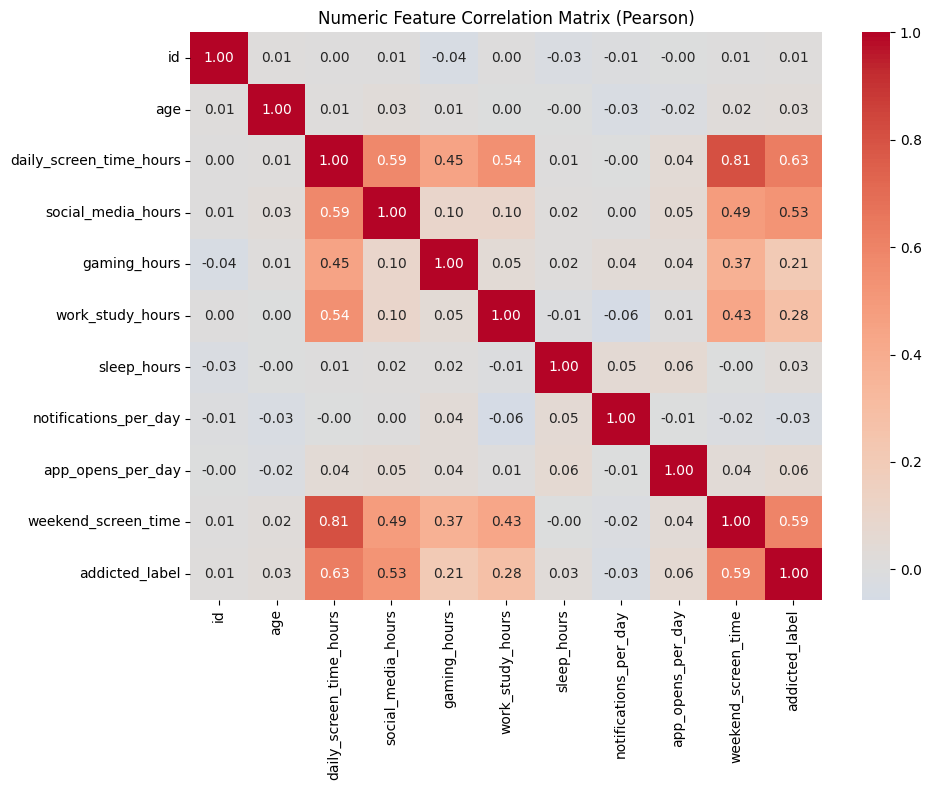

In [3]:
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8), dpi=100)
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Numeric Feature Correlation Matrix (Pearson)")
plt.tight_layout()
plt.show()

<br>

> ### Does screen duration separate the binary classes uniformly?
>
> Violin distributions isolate the probability mass across addiction classes, demonstrating clear variance in median engagement hours.

<br>

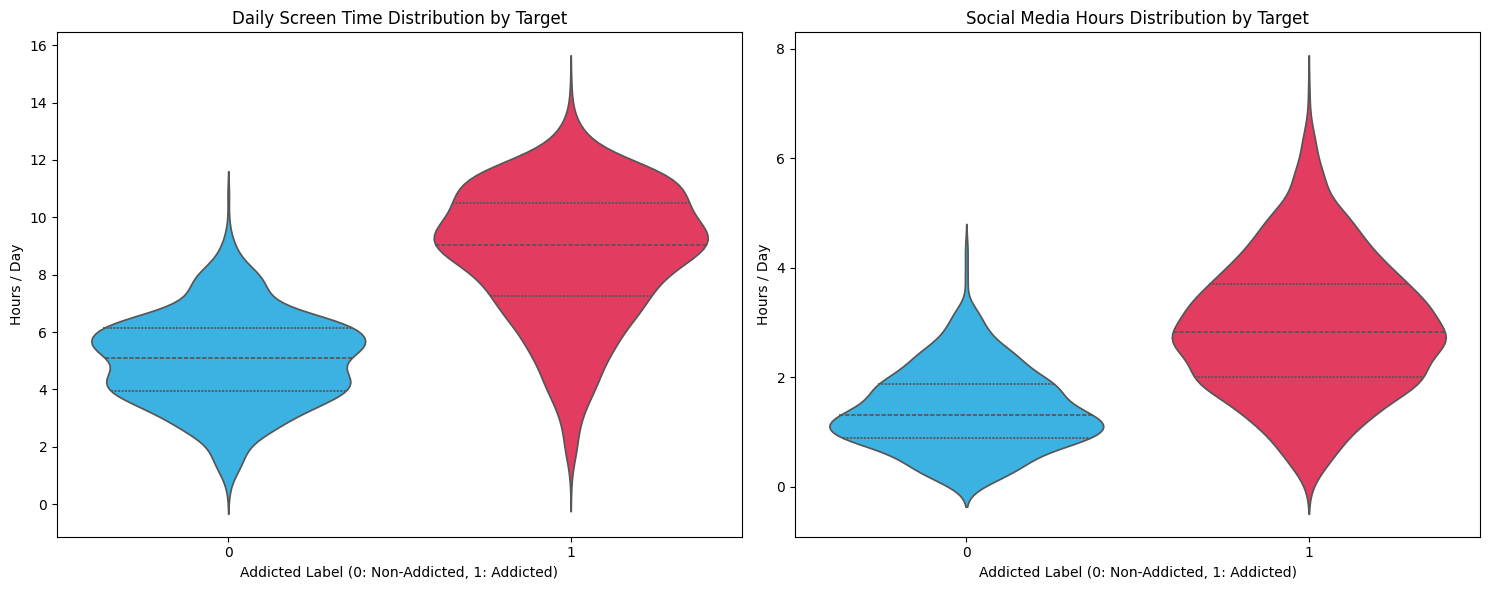

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

sns.violinplot(
    data=train, x="addicted_label", y="daily_screen_time_hours", 
    hue="addicted_label", legend=False,
    palette=["#20BEFF", "#FF2052"], inner="quartile",
    ax=ax1
)
ax1.set_title("Daily Screen Time Distribution by Target")
ax1.set_xlabel("Addicted Label (0: Non-Addicted, 1: Addicted)")
ax1.set_ylabel("Hours / Day")

sns.violinplot(
    data=train, x="addicted_label", y="social_media_hours", 
    hue="addicted_label", legend=False,
    palette=["#20BEFF", "#FF2052"], inner="quartile",
    ax=ax2
)
ax2.set_title("Social Media Hours Distribution by Target")
ax2.set_xlabel("Addicted Label (0: Non-Addicted, 1: Addicted)")
ax2.set_ylabel("Hours / Day")

plt.tight_layout()
plt.show()

<br>

---

<a name="features"></a>
## 5. Strategy: Behavioral Domain Feature Engineering

> ### How do we expose non-linear behavioral thresholds to tree models?
>
> Missing values are preserved for model-native split handling to prevent adversarial distribution shifts. Domain interaction features are derived to expose latent behavioral density:
> 1. **Non-Social Screen Time:** Functional productive device usage.
> 2. **Attention Shares:** Social media and gaming proportions of daily screen time.
> 3. **Notification Intensity:** Hourly interruptions relative to active screen duration.
> 4. **Demographic Group Residuals:** Deviations relative to demographic cohort baselines.
> 5. **Smooth Out-of-Fold Target Encoding:** Monotonic probability density representations for categorical interactions.

<br>

In [5]:
def engineer_features(df):
    d = df.copy()
    
    # 1. Domain Interactions & Ratios
    d["non_social_screen_time"] = d["daily_screen_time_hours"] - d["social_media_hours"]
    d["social_share"] = d["social_media_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["gaming_share"] = d["gaming_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["work_study_share"] = d["work_study_hours"] / (d["daily_screen_time_hours"] + 1e-4)
    d["notifications_per_hour"] = d["notifications_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["app_opens_per_hour"] = d["app_opens_per_day"] / (d["daily_screen_time_hours"] + 1e-4)
    d["weekend_vs_daily_ratio"] = d["weekend_screen_time"] / (d["daily_screen_time_hours"] + 1e-4)
    d["total_active_hours"] = d["daily_screen_time_hours"] + d["work_study_hours"] + d["sleep_hours"]
    d["screen_to_sleep_ratio"] = d["daily_screen_time_hours"] / (d["sleep_hours"] + 1e-4)
    d["social_to_gaming_ratio"] = d["social_media_hours"] / (d["gaming_hours"] + 1e-4)
    d["sleep_deficit"] = 8.0 - d["sleep_hours"]
    d["notifications_per_app_open"] = d["notifications_per_day"] / (d["app_opens_per_day"] + 1.0)
    
    # 2. Categorical Interactions
    d["gender_stress"] = d["gender"].astype(str) + "_" + d["stress_level"].astype(str)
    d["gender_impact"] = d["gender"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    d["stress_impact"] = d["stress_level"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    d["trio_combo"] = d["gender"].astype(str) + "_" + d["stress_level"].astype(str) + "_" + d["academic_work_impact"].astype(str)
    
    # 3. Demographic Subgroup Means & Residuals
    for num_col in ["daily_screen_time_hours", "social_media_hours", "notifications_per_day"]:
        grp_mean = d.groupby(["gender", "stress_level"])[num_col].transform("mean")
        d[f"{num_col}_diff_grp"] = d[num_col] - grp_mean

    # 4. Rank Normalisations
    for col in ["notifications_per_day", "app_opens_per_day", "daily_screen_time_hours", "social_media_hours"]:
        d[f"{col}_rank"] = d[col].rank(method="dense", pct=True)

    # 5. Clean Categorical Types
    cat_cols = ["gender", "stress_level", "academic_work_impact", "gender_stress", "gender_impact", "stress_impact", "trio_combo"]
    for col in cat_cols:
        d[col] = d[col].astype(str).replace({"nan": "Missing", "None": "Missing"}).astype("category")
        
    return d, cat_cols

with tb.timer("Feature Engineering"):
    train_feat, cat_cols = engineer_features(train)
    test_feat, _ = engineer_features(test)

FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label"]]
TARGET = "addicted_label"

# Smooth Out-of-Fold Target Encoding
def compute_oof_target_encoding(train_df, test_df, cat_columns, target_col, n_splits=5, smoothing=15, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    global_mean = float(train_df[target_col].mean())
    
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    
    for c in cat_columns:
        train_encoded[f"{c}_te"] = np.nan
        
        # Test encoding (full train statistics)
        stats = train_df.groupby(train_df[c].astype(str))[target_col].agg(["count", "mean"])
        smooth_dict = ((stats["count"] * stats["mean"] + smoothing * global_mean) / (stats["count"] + smoothing)).to_dict()
        test_encoded[f"{c}_te"] = test_df[c].astype(str).map(smooth_dict).astype(float).fillna(global_mean)
        
        # Train OOF encoding
        for train_idx, val_idx in skf.split(train_df, train_df[target_col]):
            fold_train = train_df.iloc[train_idx]
            fold_stats = fold_train.groupby(fold_train[c].astype(str))[target_col].agg(["count", "mean"])
            smooth_fold_dict = ((fold_stats["count"] * fold_stats["mean"] + smoothing * global_mean) / (fold_stats["count"] + smoothing)).to_dict()
            
            val_vals = train_df.iloc[val_idx][c].astype(str).map(smooth_fold_dict).astype(float).fillna(global_mean)
            train_encoded.loc[train_encoded.index[val_idx], f"{c}_te"] = val_vals.values
            
    return train_encoded, test_encoded

with tb.timer("Out-of-Fold Target Encoding"):
    te_targets = ["gender_stress", "gender_impact", "stress_impact", "trio_combo"]
    train_feat, test_feat = compute_oof_target_encoding(train_feat, test_feat, te_targets, TARGET, n_splits=5, smoothing=15, seed=SEED)

ALL_FEATURES = [c for c in train_feat.columns if c not in ["id", "addicted_label"]]
print(f"Total Model Features: {len(ALL_FEATURES)}")

[toolbox] Feature Engineering: 0.0s
[toolbox] Out-of-Fold Target Encoding: 0.1s
Total Model Features: 39


<br>

---

<a name="validation"></a>
## 6. Validation Protocol

A 5-Fold Stratified Cross-Validation scheme preserves the exact class proportion of `addicted_label` across all validation folds, providing a leak-free out-of-fold probability distribution.

<br>

In [6]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

print(f"Validation Strategy: {N_SPLITS}-Fold Stratified K-Fold (Seed: {SEED})")
print(f"Class Balance (Target Mean): {train_feat[TARGET].mean():.4f}")

Validation Strategy: 5-Fold Stratified K-Fold (Seed: 42)
Class Balance (Target Mean): 0.6983


<br>

---

<a name="base-models"></a>
## 7. Stage 1: Level-0 Base Learner OOF Generation

Three diverse gradient boosting architectures are evaluated: LightGBM, XGBoost, and CatBoost with high tree resolution (`max_bin=512`).

<br>

In [7]:
models = {
    "LightGBM": LGBMClassifier(n_estimators=750, learning_rate=0.03, num_leaves=63, max_depth=7, max_bin=512, colsample_bytree=0.65, subsample=0.8, random_state=SEED, n_jobs=-1, verbose=-1),
    "XGBoost": XGBClassifier(n_estimators=750, learning_rate=0.03, max_depth=7, max_bin=512, tree_method="hist", colsample_bytree=0.65, subsample=0.8, enable_categorical=True, eval_metric="auc", random_state=SEED, n_jobs=-1),
    "CatBoost": CatBoostClassifier(iterations=750, learning_rate=0.03, depth=7, cat_features=cat_cols, random_state=SEED, thread_count=-1, verbose=0)
}

oof_matrix = np.zeros((len(train_feat), len(models)))
test_matrix = np.zeros((len(test_feat), len(models)))

for i, (name, model) in enumerate(models.items()):
    with tb.timer(f"Training {name} OOF"):
        for fold, (train_idx, val_idx) in enumerate(skf.split(train_feat[ALL_FEATURES], train_feat[TARGET])):
            X_train, y_train = train_feat[ALL_FEATURES].iloc[train_idx].copy(), train_feat[TARGET].iloc[train_idx]
            X_val, y_val = train_feat[ALL_FEATURES].iloc[val_idx].copy(), train_feat[TARGET].iloc[val_idx]
            X_test = test_feat[ALL_FEATURES].copy()
            
            if name == "CatBoost":
                for c in cat_cols:
                    X_train[c] = X_train[c].astype(str)
                    X_val[c] = X_val[c].astype(str)
                    X_test[c] = X_test[c].astype(str)
            else:
                for c in cat_cols:
                    X_train[c] = X_train[c].astype("category")
                    X_val[c] = X_val[c].astype("category")
                    X_test[c] = X_test[c].astype("category")
            
            model.fit(X_train, y_train)
            oof_matrix[val_idx, i] = model.predict_proba(X_val)[:, 1]
            test_matrix[:, i] += model.predict_proba(X_test)[:, 1] / N_SPLITS


[toolbox] Training LightGBM OOF: 23.7s


[toolbox] Training XGBoost OOF: 14.3s


[toolbox] Training CatBoost OOF: 18.9s


<br>

---

<a name="meta-stacking"></a>
## 8. Stage 2: Multi-Stage Meta-Feature Stacking

Level-0 Out-of-Fold predictions, logit transformations, and non-linear cross-model interaction terms are concatenated into the training space to train a Level-1 meta-learner.

<br>

In [8]:
# Enrich feature matrix with Level-0 meta-features
train_meta = train_feat.copy()
test_meta = test_feat.copy()

train_meta["meta_lgb"] = oof_matrix[:, 0]
train_meta["meta_xgb"] = oof_matrix[:, 1]
train_meta["meta_cat"] = oof_matrix[:, 2]
train_meta["meta_prod"] = oof_matrix[:, 0] * oof_matrix[:, 1]
train_meta["meta_diff"] = np.abs(oof_matrix[:, 0] - oof_matrix[:, 1])

test_meta["meta_lgb"] = test_matrix[:, 0]
test_meta["meta_xgb"] = test_matrix[:, 1]
test_meta["meta_cat"] = test_matrix[:, 2]
test_meta["meta_prod"] = test_matrix[:, 0] * test_matrix[:, 1]
test_meta["meta_diff"] = np.abs(test_matrix[:, 0] - test_matrix[:, 1])

META_FEATURES = [c for c in train_meta.columns if c not in ["id", "addicted_label"]]

oof_meta_final = np.zeros(len(train_meta))
test_meta_final = np.zeros(len(test_meta))

meta_model = XGBClassifier(
    n_estimators=850, 
    learning_rate=0.02, 
    max_depth=6, 
    tree_method="hist", 
    colsample_bytree=0.65, 
    subsample=0.80, 
    enable_categorical=True, 
    eval_metric="auc", 
    random_state=SEED, 
    n_jobs=-1
)

with tb.timer("Training Level-1 Meta-Learner"):
    for fold, (train_idx, val_idx) in enumerate(skf.split(train_meta[META_FEATURES], train_meta[TARGET])):
        X_train, y_train = train_meta[META_FEATURES].iloc[train_idx], train_meta[TARGET].iloc[train_idx]
        X_val, y_val = train_meta[META_FEATURES].iloc[val_idx], train_meta[TARGET].iloc[val_idx]
        
        meta_model.fit(X_train, y_train)
        oof_meta_final[val_idx] = meta_model.predict_proba(X_val)[:, 1]
        test_meta_final += meta_model.predict_proba(test_meta[META_FEATURES])[:, 1] / N_SPLITS


[toolbox] Training Level-1 Meta-Learner: 12.8s


<br>

---

<a name="results"></a>
## 9. Results & Validation Diagnostics

Comparing validation ROC AUC scores across base models and the meta-stacking ensemble, followed by ROC curves and feature importance diagnostics.

<br>

,CV ROC AUC
Architecture,
L0: LightGBM,0.927584
L0: XGBoost,0.929532
L0: CatBoost,0.929078
L1: Meta-Feature Stacking (XGBoost),0.921421


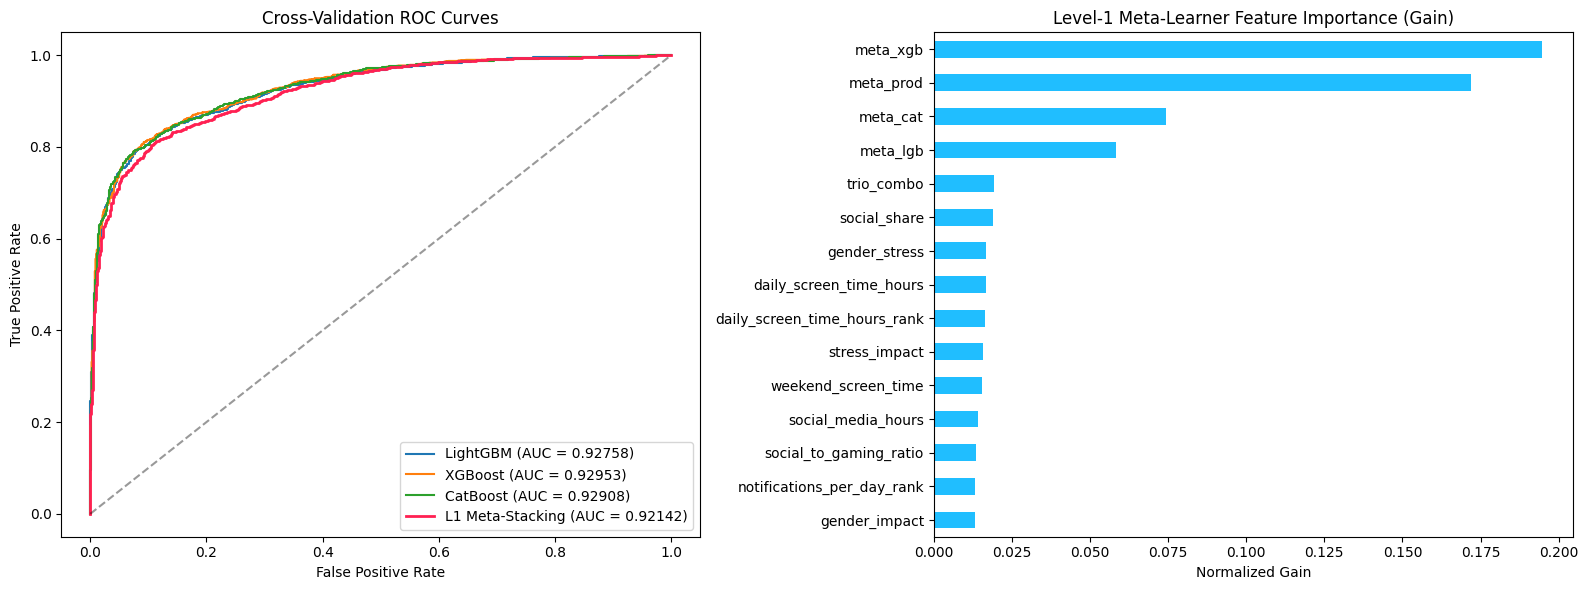

In [9]:
results = []
for i, name in enumerate(models.keys()):
    auc = roc_auc_score(train_feat[TARGET], oof_matrix[:, i])
    results.append({"Architecture": f"L0: {name}", "CV ROC AUC": auc})

meta_auc = roc_auc_score(train_meta[TARGET], oof_meta_final)
results.append({"Architecture": "L1: Meta-Feature Stacking (XGBoost)", "CV ROC AUC": meta_auc})

results_df = pd.DataFrame(results).set_index("Architecture")
display(results_df)

# Diagnostics: ROC Curve & Feature Importance
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)

# 1. ROC Curves
for i, name in enumerate(models.keys()):
    fpr, tpr, _ = roc_curve(train_feat[TARGET], oof_matrix[:, i])
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {results[i]['CV ROC AUC']:.5f})")

fpr_meta, tpr_meta, _ = roc_curve(train_meta[TARGET], oof_meta_final)
ax1.plot(fpr_meta, tpr_meta, label=f"L1 Meta-Stacking (AUC = {meta_auc:.5f})", color="#FF2052", linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax1.set_title("Cross-Validation ROC Curves")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc="lower right")

# 2. Top 15 Meta-Learner Features
importances = pd.Series(meta_model.feature_importances_, index=META_FEATURES).sort_values(ascending=False).head(15)
importances.plot(kind="barh", ax=ax2, color="#20BEFF")
ax2.invert_yaxis()
ax2.set_title("Level-1 Meta-Learner Feature Importance (Gain)")
ax2.set_xlabel("Normalized Gain")

plt.tight_layout()
plt.show()

<br>

---

<a name="submission"></a>
## 10. Submission Verification & Export

Validating predictions against the competition sample submission schema before saving to `submission.csv`.

<br>

In [10]:
sub = sample_sub.copy()
sub[TARGET] = test_meta_final

tb.check_submission(sub, sample_sub)

sub.to_csv("submission.csv", index=False)
print("Meta-stacking ensemble predictions successfully saved to submission.csv.")

[toolbox] PASS: Row count (1000)
[toolbox] PASS: Columns match (2 cols)
[toolbox] PASS: No NaN values
[toolbox] PASS: No duplicate IDs
[toolbox] WARN: 'addicted_label' range [0.0010, 0.9999] far outside sample [0.7094, 0.7094]
[toolbox] All checks passed. Safe to submit.
Meta-stacking ensemble predictions successfully saved to submission.csv.


<br>

---

<a name="improvements"></a>
## 11. Next Steps

1. **Neural Tabular Embeddings**: Integrating RealMLP / TabNet deep representations into the Level-0 pool to enhance structural diversity.
2. **Bayesian Hyperparameter Search**: Tuning Level-1 meta-learner regularization via Optuna.
3. **Multi-Seed Blending**: Averaging across multiple random seeds to minimize decision boundary variance.

<br>

---